#Discovering the Prime Age of Basketball Players

#Permissions


    [X] YES - make available
    [ ] NO - keep private


# Names:  
Austin Choi  
Seth Chng  
Chester Huey  
Ethaniel Reyes


#Abstract

Our project sought to analyze the correlation between NBA players’ performance and their age. To do this, we picked out a random sample of NBA players from datasets compiled in the reference website Basketball Reference. Using performance-based metrics such as points, assists, and shot accuracy, we used common data analysis tools in Python to visually plot the relationships in graphs and conduct T-tests between players performing at different age levels.


Building on the background of our research, where we identified a gap in the existing studies focusing primarily on All-Stars or top-tier NBA players, we aimed to take a more comprehensive approach to our analysis. Prior studies relied on smaller sample sizes, such as the one that concluded a player’s prime years fall between ages 27 and 31, and they were often limited to the top 30 players. While those studies provided valuable insights, they lacked inclusivity, failing to account for the performance patterns of role players and bench contributors who make up the majority of NBA rosters. Given that General Managers (GMs) and franchise decision-makers are responsible for managing entire rosters, not just superstar talent, our research sought to provide a broader, data-driven analysis applicable to the full spectrum of NBA athletes. Our project found that the peak performance of NBA basketball players was a slightly lower age than expected and this result is explainable due to our data.


# Research Question

At what age do NBA players, across all those studied on Basketball Reference, perform at their peak in terms of individual statistics such as points and field goal percentage, and how can we determine the point in their careers when they provide the most successful results?


# Background and prior work
Our topic will be mostly focused around the performance of athletes in the NBA. We believe we can make an accurate predictor or make a project that can determine a player's peak age. This information will be valuable for GM’s and franchises trying to make million-dollar decisions paying for different players. We looked into sites that contain information about NBA players and each of them are listed below in the data section. First, we found the website Basketball Reference which has all the data we believe we will need in CSV format. Next, we discussed potential sub-questions relevant to our data: for example, comparing home vs away performances, games in warm weather vs cold weather, and the years of an athlete's prime. We even considered studying how sports and wins related to traffic and domestic abuse cases, but struggled to find datasets that could provide the data we needed.

While considering these ideas, we considered the data we had. We decided against studying the correlation to weather, since we lacked the relevant weather information. Then, between studying athletes’ prime and comparing home vs away performances, we chose the former as our research topic. There was already a lot of prior research and understanding comparing home and away performances, and our dataset has a lot less information on team stats compared to individuals. We then chose to specify the scope of our project, and collectively decided to study all types of NBA players. We believe that GM’s and ownership have to make decisions on all players, not just a select few.

The link [here](https://digitalcommons.bryant.edu/cgi/viewcontent.cgi?article=1223&context=eeb) is an in depth study about the prime years of a player, but it mostly focuses on an age range. They also have several limitations that they mentioned in the study (a small sample size and they selected the top 30 players). They came to the conclusion that the best age for peak performance in the NBA is between 27-31. Our research aims to confirm their suspicions, pinpoint an age, and bring a new perspective by adding in role players along with All stars (the top players in the league that was researched in the last study). This link [here](https://hoopshype.com/2018/12/31/nba-aging-curve-father-time-prime-lebron-james-decline/) is a less professional study, but the conclusion is similar. They used all NBA selections along with all star appearances and came to the conclusion that 27 is the optimal age.


Bryant University Study: Cohen, Jeffrey S., et al. "An In-Depth Study of NBA Player Performance and Aging: An Examination of the Peak Years." Bryant University, 2018, https://digitalcommons.bryant.edu/cgi/viewcontent.cgi?article=1223&context=eeb.

CEPAR Article: Chomik, Rafal, and Michael Jacinto. "Peak Performance Age in Sport: A Focus on Basketball." CEPAR, 2020, https://cepar.edu.au/sites/default/files/peak-performance-age-sport.pdf .

HoopsHype Article: "The NBA Aging Curve: When Does Father Time Catch Up with LeBron and Others?" HoopsHype, 31 Dec. 2018, https://hoopshype.com/2018/12/31/nba-aging-curve-father-time-prime-lebron-james-decline/.

# Hypothesis
We predict that an NBA player will tend to have better individual statistics before the age of 30. From what we have seen in the Bryant and Cepar studies, players tend to have their best gameplay statistics between the ages of 27-31.


# Data
Dataset #1
- Total_df, which is the total basic stats of all the players we will conduct our study on.
- The link to the dataset we will be using is [here](https://github.com/COGS108/Group074_WI25/blob/master/totalsstatssheet.csv).
- This dataset has 11847 observations.
- There are 33 variables.

Dataset #2.  
- Advanced_df, which are the advanced stats of all the players we will conduct our study on.
- The link to the dataset we will be using is [here](https://github.com/COGS108/Group074_WI25/blob/master/advancedstatssheet.csv).
- This dataset has 10770 observations.
- There are 30 variables.

The two links for our data were stats of players taken directly from [basketball reference](https://www.basketball-reference.com/)

Our first dataset, Total_df contains player-level statistics such as points per game (PPG), assists per game (APG), rebounds per game (RPG), along with demographic information like player name, team, and age for each NBA season. Most metrics (PPG, APG, RPG, etc.) are numeric (float or integer), while player details like names and teams are categorical (strings). These metrics can serve as indicators for overall performance, efficiency, and role on a team.

The second datset, Advanced_df includes advanced metrics such as Player Efficiency Rating (PER), Win Shares (WS), and Box Plus/Minus (BPM), as well as information on All-Star selections or MVP awards. These advanced metrics are numeric and from underlying box-score data, giving a deeper insight into individual impact and efficiency. The awards or honors are typically categorical or boolean (e.g., “All-Star = True/False”), serving as key points for peak recognition or standout performance.

We plan on relating the two datasets by sorting by individual players, utilizing statistics from each of them separately.

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/TotalsStatSheet.csv'

# Read the CSV file
total_df = pd.read_csv(file_path)

# Remove years where the player did not play.
def remove_dnp_injury_from_all_columns(df):
    df_cleaned = df[~df.isin(['Did not play - injury']).any(axis=1)]
    return df_cleaned

# Remove games where the player sat out a whole season
def remove_sat_out_columns(df):
    df_cleaned = df[~df.isin(['Did not play - sat out']).any(axis=1)]
    return df_cleaned

#calling the functions on our datasets
total_df = remove_dnp_injury_from_all_columns(total_df)
total_df = remove_sat_out_columns(total_df)

# Selecting columns that are supposed to be numeric and converting them to float
columns = ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']
total_df[columns] = total_df[columns].astype(float)
total_df[columns] = total_df[columns].fillna(0)

#dropping columns with inconsistent data
total_df = total_df.drop('Awards', axis=1)
total_df = total_df.drop('Trp-Dbl', axis=1)

# clearing all null values from the dataframes
total_df = total_df.dropna()

In [ ]:
file_path1 = '/content/drive/My Drive/advancedstatssheet.csv'

# Read the CSV files
advanced_df = pd.read_csv(file_path1)

#calling the functions on our datasets
advanced_df = remove_dnp_injury_from_all_columns(advanced_df)
advanced_df = remove_sat_out_columns(advanced_df)

# Selecting columns that are supposed to be numeric and converting them to float
columns = ['Age', 'G', 'GS', 'MP', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP']
advanced_df[columns] = advanced_df[columns].astype(float)

advanced_df = advanced_df.drop('Awards', axis=1)
# clearing all null values from the dataframes
advanced_df = advanced_df.dropna()

In [ ]:
# Eliminating players who didn't play more than half the games that season, because their stats might be inflated/deflated due to lack of games played

total_df = total_df[total_df['G'] > 40.0]
advanced_df = advanced_df[advanced_df['G'] > 40.0]

We are using two different datasets: one comprising of total statistics among the players chosen, and one comprising of their advanced statistics.

In [ ]:
# printing out the total stats dataframe
print(total_df.head())
print(total_df.describe())

        Player     Season   Age Team   Lg Pos     G    GS      MP     FG  ...  \
0  Brook Lopez  2008-2009  20.0  NJN  NBA   C  82.0  75.0  2501.0  448.0  ...   
1  Brook Lopez  2009-2010  21.0  NJN  NBA   C  82.0  82.0  3027.0  563.0  ...   
2  Brook Lopez  2010-2011  22.0  NJN  NBA   C  82.0  82.0  2889.0  644.0  ...   
4  Brook Lopez  2012-2013  24.0  BRK  NBA   C  74.0  74.0  2253.0  570.0  ...   
6  Brook Lopez  2014-2015  26.0  BRK  NBA   C  72.0  44.0  2100.0  506.0  ...   

     FT%    ORB    DRB    TRB    AST   STL    BLK    TOV     PF     PTS  
0  0.793  225.0  440.0  665.0   86.0  44.0  151.0  147.0  257.0  1068.0  
1  0.817  270.0  439.0  709.0  187.0  55.0  139.0  204.0  251.0  1542.0  
2  0.787  197.0  291.0  488.0  129.0  47.0  120.0  176.0  240.0  1673.0  
4  0.758  208.0  304.0  512.0   70.0  33.0  154.0  131.0  152.0  1437.0  
6  0.814  214.0  321.0  535.0   50.0  43.0  126.0  104.0  206.0  1236.0  

[5 rows x 31 columns]
              Age           G          GS     

In [ ]:
# printing out the advanced stats dataframe
print(advanced_df.head())
print(advanced_df.describe())

        Player   Season   Age Team   Lg Pos     G    GS      MP   PER  ...  \
0  Brook Lopez  2008-09  20.0  NJN  NBA   C  82.0  75.0  2501.0  17.9  ...   
1  Brook Lopez  2009-10  21.0  NJN  NBA   C  82.0  82.0  3027.0  20.1  ...   
2  Brook Lopez  2010-11  22.0  NJN  NBA   C  82.0  82.0  2889.0  19.3  ...   
4  Brook Lopez  2012-13  24.0  BRK  NBA   C  74.0  74.0  2253.0  24.7  ...   
6  Brook Lopez  2014-15  26.0  BRK  NBA   C  72.0  44.0  2100.0  22.7  ...   

   TOV%  USG%  OWS  DWS   WS  WS/48  OBPM  DBPM  BPM  VORP  
0  13.5  20.3  3.2  2.7  5.8  0.112  -0.3  -0.3 -0.6   0.9  
1  13.1  23.6  5.5  2.4  7.9  0.125   1.6  -0.5  1.2   2.5  
2  10.4  27.3  4.4  1.9  6.3  0.105   1.4  -0.9  0.6   1.9  
4   9.4  28.6  6.4  2.6  9.0  0.191   3.4  -0.2  3.2   3.0  
6   8.6  26.3  4.7  2.2  7.0  0.159   1.8  -0.7  1.2   1.6  

[5 rows x 29 columns]
              Age           G          GS           MP         PER  \
count  295.000000  295.000000  295.000000   295.000000  295.000000   
me

#Results

## Plotting Statistics

Here are functions that make graphs to help us visualize our data. We took the average of individual statistics that we felt reflected a players prime and saw how they changed over time.



To help us visualize our data, we created three functions and looped over all statistics, graphing them individually.

Our `makestatgraphT` function specifies a particular statistic as an input. It then extracts a new dataframe from our `total_df` with the statistic of interest, groups by age, and averages the statistic over all players. It then uses a lineplot to describe the relationship.

The `pmakestatgraphT` function works similarly, but the graphs have a y-axis set between `[0, 1]`. This function is used to plot out percentage statistics, such as 2-point or 3-point percentages.

The `makestatgraphA` function works precisely like `makestatgraphT`, but extracts data from `advanced_df` to plot advanced statistics.

The `makestatgraphA2` function works precisely like `makestatgraphA`, but it has a different subplot size to make the graphs easier to view.

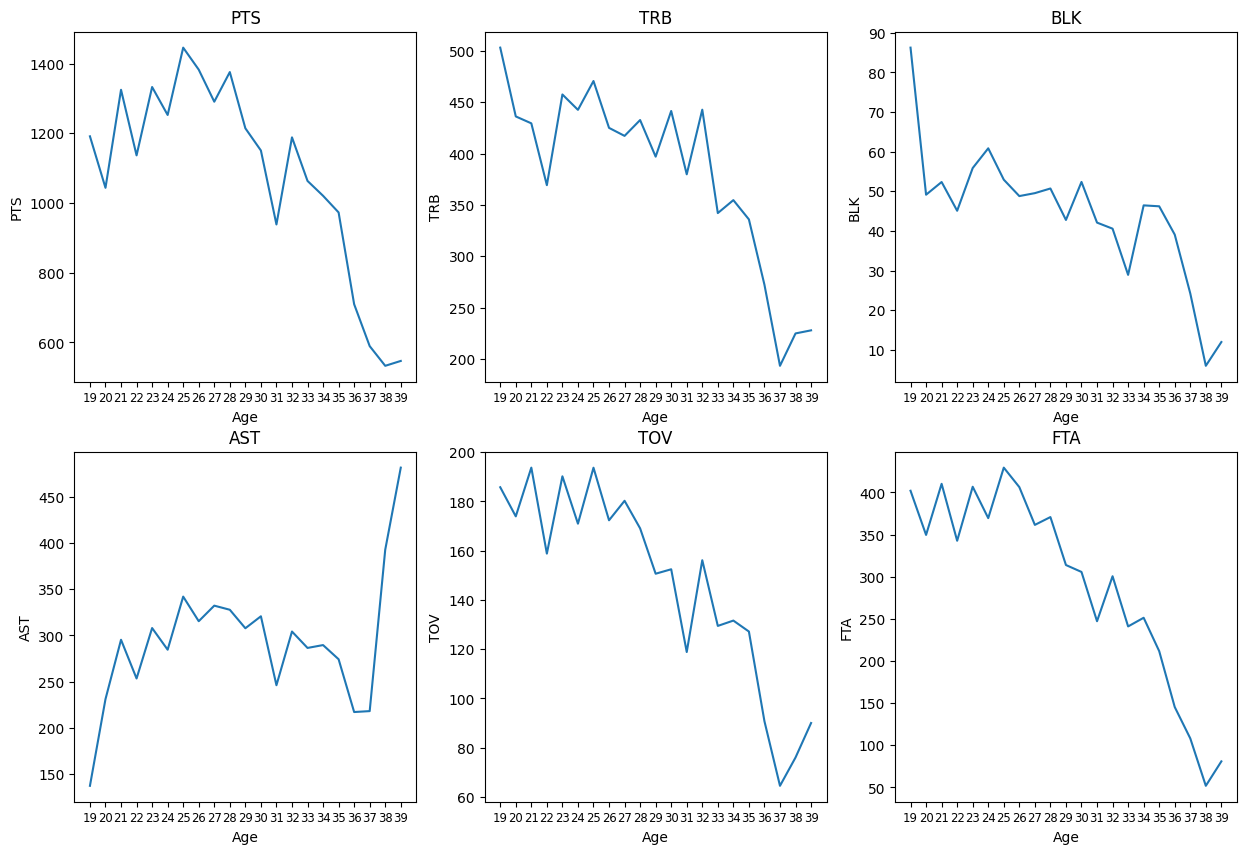

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

statsT = ['PTS', 'TRB', 'BLK', 'AST', 'TOV', 'FTA']
statsA = ['PER', 'WS','BPM','VORP']
pStatsT = ['2P%' , '3P%', 'FG%','eFG%']
pStatsA = ['TS%','USG%']

def makestatgraphT(ax, stat):
    avg_by_age = total_df.groupby("Age")[stat].mean().reset_index()
    sns.lineplot(data=avg_by_age, x="Age", y=stat, ax=ax)  # Plot on the specific subplot
    ax.set_xticks(np.arange(int(total_df['Age'].min()), int(total_df['Age'].max()) + 1, 1))
    ax.set_title(stat)
    # Set the font size of x-axis tick labels
    labels = [item.get_text() for item in ax.get_xticklabels()]
    ax.set_xticklabels(labels, fontsize='small')

# Create subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten axes array for easier indexing
axes = axes.flatten()

#for stat in pStatsT:
  #pmakestatgraphT(stat)
# Generate each subplot
for i, stat in enumerate(statsT):
    makestatgraphT(axes[i], stat)

Looking at the first 6 graphs from our totalstats dataframe, it appears a majority of the stats peak earlier in the career and fall off late. Assists is a completely different story, but there is an outlier player skewing that number to be higher.

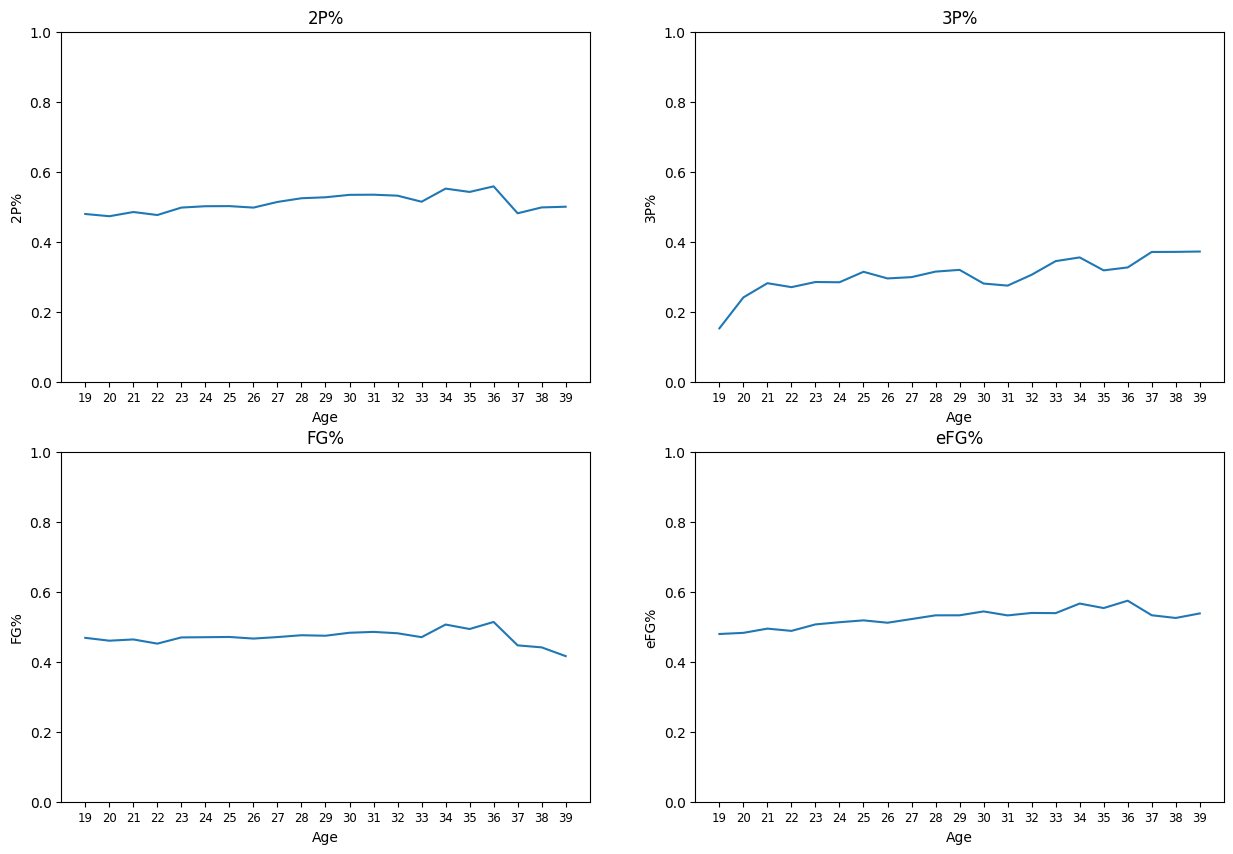

In [ ]:
def pmakestatgraphT(ax, stat):
  avg_by_age = total_df.groupby("Age")[stat].mean().reset_index()
  sns.lineplot(data=avg_by_age, x="Age", y=stat, ax=ax)  # Plot on the specific subplot
  ax.set_xticks(np.arange(int(total_df['Age'].min()), int(total_df['Age'].max()) + 1, 1))
  ax.set_title(stat)
  ax.set_ylim(0,1)

  # Set the font size of x-axis tick labels
  labels = [item.get_text() for item in ax.get_xticklabels()]
  ax.set_xticklabels(labels, fontsize='small')

# Create subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Flatten axes array for easier indexing
axes = axes.flatten()

for i, stat in enumerate(pStatsT):
    pmakestatgraphT(axes[i], stat)

Looking at the shooting percentages of the players selected in our dataframe, there seems to be no evidence of age playing a part on how well a player shoots throughout their career as it seems pretty consistent.

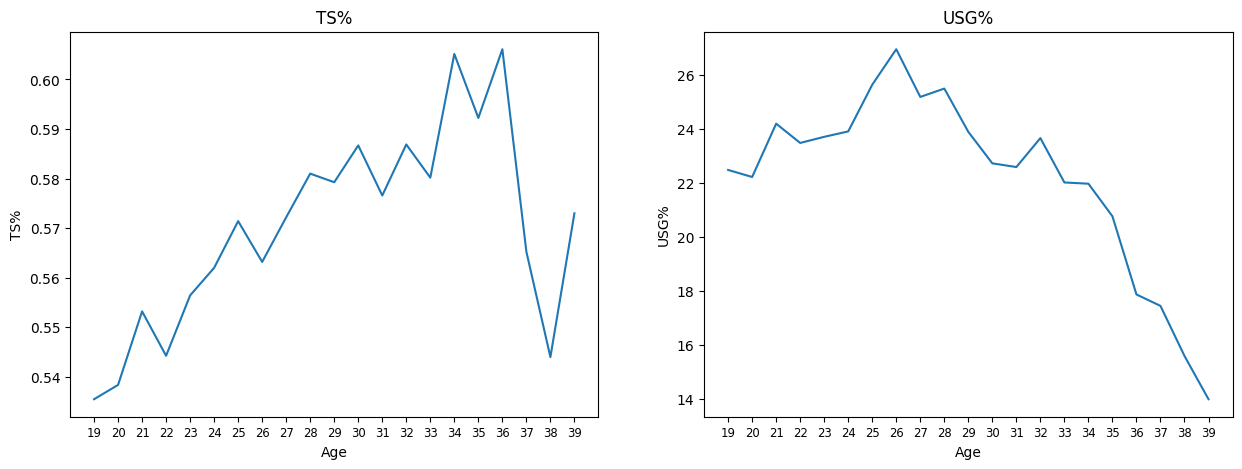

In [ ]:
def makestatgraphA(ax, stat):
  avg_by_age = advanced_df.groupby("Age")[stat].mean().reset_index()
  sns.lineplot(data=avg_by_age, x="Age", y=stat, ax=ax)  # Plot on the specific subplot
  ax.set_xticks(np.arange(int(advanced_df['Age'].min()), int(advanced_df['Age'].max()) + 1, 1))
  ax.set_title(stat)
  # Set the font size of x-axis tick labels
  labels = [item.get_text() for item in ax.get_xticklabels()]
  ax.set_xticklabels(labels, fontsize='small')

# Create subplots (2 rows, 3 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Flatten axes array for easier indexing
axes = axes.flatten()

# running graphs for the advanced table
for i, stat in enumerate(pStatsA):
    makestatgraphA(axes[i], stat)

For these graphs, the true shooting of a player seems to increase as the years go by, but their usage decreases. This means that a player makes more of their shots while they get older, but they also get to be put on the court for a lot less time as well.

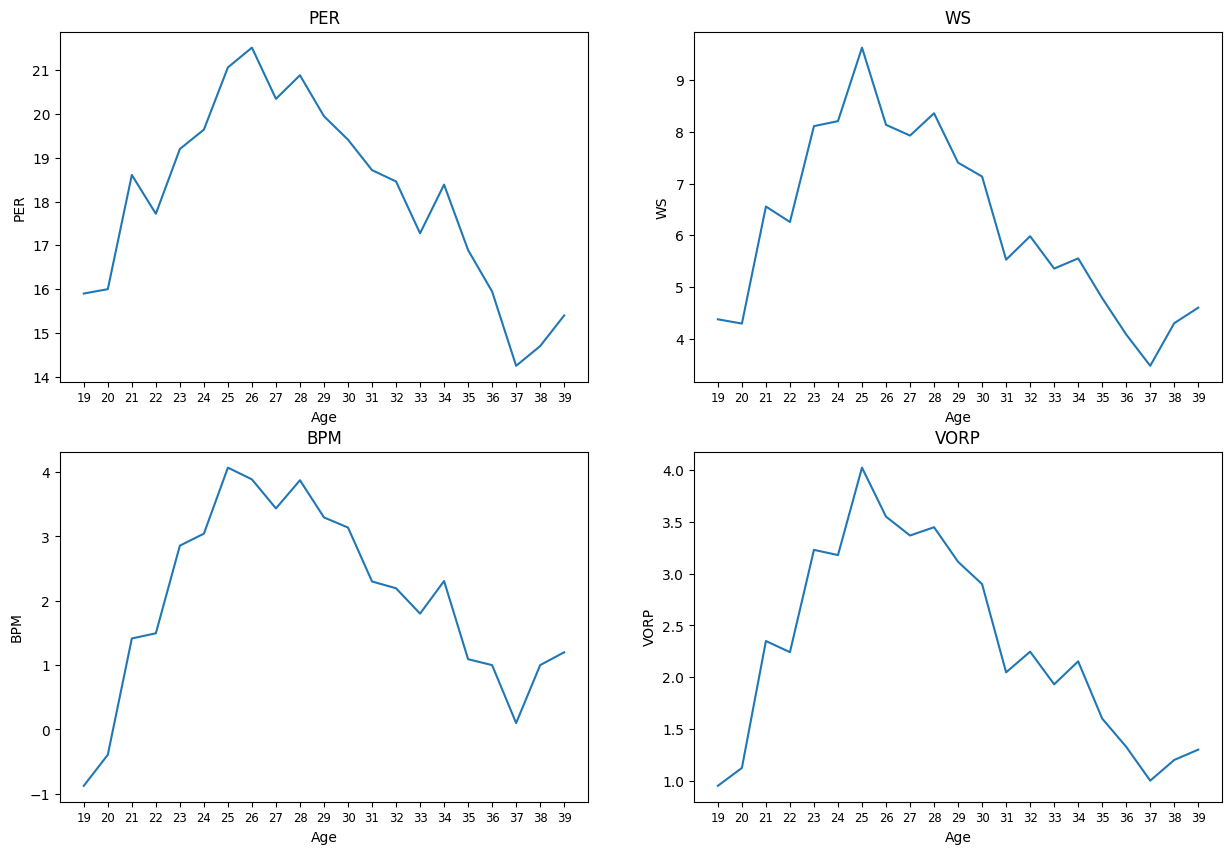

In [ ]:
def makestatgraphA2(ax, stat):
  avg_by_age = advanced_df.groupby("Age")[stat].mean().reset_index()
  sns.lineplot(data=avg_by_age, x="Age", y=stat, ax=ax)  # Plot on the specific subplot
  ax.set_xticks(np.arange(int(advanced_df['Age'].min()), int(advanced_df['Age'].max()) + 1, 1))
  ax.set_title(stat)
  # Set the font size of x-axis tick labels
  labels = [item.get_text() for item in ax.get_xticklabels()]
  ax.set_xticklabels(labels, fontsize='small')

# Create subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Flatten axes array for easier indexing
axes = axes.flatten()

for i, stat in enumerate(statsA):
    makestatgraphA2(axes[i], stat)

Finally for these stats, these distributions clearly peak around the age 25 and then decrease from there. What these graphs are graphing are how many points up or down a player is per 100 minutes, and their value over a replacement player. So it appears around age 25 these graphs demonstrate that a player has their highest plus/minus and value over a replacement.

# Carrying Out Data Analysis

We sought to compare statistics between NBA players that were over under 30. To do this, we created two functions here to carry out T-tests. We wrote the functions `calcpvalT` and `calcpvalA`, which passes a statistics `stat` we are interested in as an input.

We set up the functions so that `calcpvalT` extracts  from the dataframe `total_df`, while `calcpvalA` extracts from `advanced_df`.

The functions extract all the information in the `stat` column, then stratify all entries between two smaller dataframes. `prime_players` consists of all entries with a recorded age under 30, while `old_players` consists all entries with recorded age of 30 or older.

We then use the `stats.ttest_ind()` function to perform a T-test between `prime_players` and `old_players`, then relayed our `p-value` for that particular statistic `stat`.

In [ ]:
from scipy import stats
# Pvalue calculations for testing of our hypothesis

#Our datas prime
#prime_players = advanced_df[(advanced_df[age] < 30) & (advanced_df[age] >= 24)][stat]
#old_players = advanced_df[(advanced_df[age] >= 30) | (advanced_df[age] < 24)][stat]

#prior research prime
#prime_players = advanced_df[(advanced_df[age] < 32) & (advanced_df[age] >= 27)][stat]
#old_players = advanced_df[(advanced_df[age] >= 32) | (advanced_df[age] < 27)][stat]

def calcpvalT(age, stat):
  prime_players = total_df[total_df[age] < 30][stat]
  old_players = total_df[total_df[age] >= 30][stat]

  t_statistic, p_value = stats.ttest_ind(prime_players, old_players)
  print(stat)
  print("P-value:", p_value)

def calcpvalA(age, stat):
  prime_players = advanced_df[advanced_df[age] < 30][stat]
  old_players = advanced_df[advanced_df[age] >= 30][stat]

  t_statistic, p_value = stats.ttest_ind(prime_players, old_players)
  print(stat)
  print("P-value:", p_value)


Here are the results of our T-tests for the players' total statistics, pulling from `total_df`.

In [ ]:
for val in statsT:
  calcpvalT('Age', val)
for val in pStatsT:
  calcpvalT('Age', val)

PTS
P-value: 1.2441678850102743e-05
TRB
P-value: 0.009268658256336533
BLK
P-value: 0.039801956251249396
AST
P-value: 0.47427028216236555
TOV
P-value: 1.5134837202869907e-06
FTA
P-value: 2.2673678990164616e-08
2P%
P-value: 6.027562658983956e-07
3P%
P-value: 0.08936454656985438
FG%
P-value: 0.010238533473526748
eFG%
P-value: 3.4536524407725264e-09


The T-test results for general statistics show significant differences between prime (under 30) and older (30 and above) players in several key areas. Prime players outperformed older players in points, rebounds, blocks, turnovers, free throw attempts, field goal percentage, and effective field goal percentage. However, assists and three-point percentage did not show a significant difference between the two age groups, suggesting these areas are less affected by age.

Likewise, here are the results of our T-tests for the players' advanced statistics, pulling from `advanced_df`.

In [ ]:
for val in statsA:
  calcpvalA('Age', val)
for val in pStatsA:
  calcpvalA('Age', val)

PER
P-value: 0.002828522492442833
WS
P-value: 6.314352342220092e-06
BPM
P-value: 0.04419621267290598
VORP
P-value: 0.00023253517630994337
TS%
P-value: 2.185962776593989e-06
USG%
P-value: 0.00021262439300033983


For advanced statistics, significant differences were found in player efficiency rating (PER), win shares (WS), box plus-minus (BPM), value over replacement player (VORP), true shooting percentage (TS%), and usage percentage (USG%). These reinforce the idea that prime players tend to be more efficient and impactful overall compared to older players.

# Ethics and Privacy
- The refs in an NBA game are subjective, and it is up to their interpretation to make calls.  
- We are making judgments on players based on numbers throughout their careers. They could take it poorly if we claim their best years are behind them. Our goal is to analyze historical data and patterns, not to impose personal judgment on any specific player and their capabilities.  
- We aim to find an average across historical data, recognizing the wide individual variance from player to player.  
- Due to the narrow focus of our topic, our data is generalized to this specific field.  
- Some evaluations might be subjective, such as scout reports or assessments written by coaches, which may have potential biases.  
- What is a “prime” or a player's best years? We will have to find a way to determine this using the stats available to us. Also this “prime” age is simply an aggregate finding, and many individual circumstances can affect the meaning of this from person-to-person.
- Performance data are collected in public events, so there aren’t significant implications regarding personal or health data exposure. On-court performance metrics are publicly available, and we are not delving into personal or medical information about players.
#### Data Collection and Biases:
- Since the data collection is going to be over some specified time period, we can’t say whether certain factors can create a bias over time, such as changes in playing style or advancements in training methods. The former, for example, can affect factors such as peak performance.
- What about newer players with shorter careers and time played? The peak performance of a player with one year or less worth of playtime, may have some -implications for how accurate the data is.
- We also have to be aware that there are many factors not in our datasets, which may affect a player’s metrics and performances. Things like injuries, team morale, and other individual factors can affect a player’s trajectory in a game, and are overlooked in most datasets.
#### Handling Biases:
- Addressing the bias in data collection – such as various referees and game-to-game
- We can handle biases regarding short careers by filtering out players from our dataset. Things like minimum minutes on court, games played, etc. We can then separate out players who don’t meet this threshold as they don’t meet the requirements to keep this data accurate.
- When it comes to biases regarding changes in playstyle/rules, or even the growth in newer and better training methods and equipment, we could potentially perform a sub-analysis where we have 2 separate data focusing on different time periods – for example, comparing data from 2000 - 2010 and 2010 - 2020.
- We also need to acknowledge how our analysis will not account for any hidden variables like team morale, injuries, personal issues, etc. As mentioned before, many of these variables are immeasurable in an understandable unit or would be oversensitive for many players.


#Discussion and Conclusion

Utilizing a dataset sourced from Basketball Reference, which includes comprehensive player statistics over multiple seasons, we graphed out average stats over the course a players career and conducted a series of p-value tests with a 0.1 significance level. This dataset enabled us to analyze a broad range of statistics for all NBA players, not just elite performers.

We focused on key performance metrics such as:

- Points per game (PPG)
- Assists per game (APG)
- Rebounds per game (RPG)
- Player Efficiency Rating (PER)
- 2PT and 3PT field goal percentages
- Steals and blocks
- Turnovers

We chose some of these statistics from the full dataset on Basketball Reference because they cumulatively represented the others. In other words, we carefully chose statistics that would efficiently summarize other metrics and lower the number of redundant graphs that we’d have to analyze. For example, 2-point field goal percentage references the proportion of successful 2-point attempts of all games in a year. Since this statistic relied on two different columns of data (number of successes vs. number of attempts), using this statistic eliminates the need to analyze the others. By including role players and bench players in our analysis, we provided a more accurate representation of the entire league, offering insights that are more relevant to team management and strategic planning.

##Findings
Setting up the problem, we first established a null hypothesis that states no significant difference in performance between players aged 30 and below and those over 30. Our alternative hypothesis suggested that a statistically significant difference does exist between these two age groups. If the p-value is less than 0.1, it usually means there is strong evidence to conclude that the results are statistically significant.

The results of our p-value tests consistently showed a statistically significant difference between players under 30 and those over 30 across most performance metrics. Specifically, players under 30 tend to outperform those over 30 in points, rebounds, and assists. The peak age for most key performance indicators is around 25, contrasting the previously suggested 27-31 range.

Certain statistics, such as 2PT and 3PT field goal percentages, do not correlate strongly with age. This suggests that shooting efficiency is maintained later into a player's career, possibly due to skill development and experience.

##Interpretation

Our findings suggest that NBA players often reach their statistical peak earlier than traditionally assumed. We found that the prime age for most players is around 25, aligning with the physical peak and early-career motivation to secure lucrative, long-term contracts. This is slightly younger than what prior research has shown, and this could be due to the inclusion of role players.

Role players are expected to have high athleticism and play great defense. As a result, any time a role player's athleticism regresses, they get fewer minutes in the game and, therefore, fewer chances to get better statistics. This interpretation gives a solid reasoning as to why the inclusion of role players might skew our data towards the younger side. During these years, players are typically more driven to maximize their performance, which is reflected in higher per-game averages across several key metrics.

We also had some outliers that may have skewed our data a little bit. For example, Chris Paul raised the total assist statistic for players aged 37+ by a large margin. This was due to a change in play styles to a less physically demanding role.

Even after accounting for factors like contract incentives and the impact of star players, the trend remains clear: Performance tends to decline after age 30, with most players hitting their prime well before that threshold.

Our research expands the sample size beyond just elite players. While earlier research suggested that peak performance occurs between ages 27 and 31, we wanted to have a more complete dataset, varying in performance and positions.

Our study includes all player types, from superstars to role players, and uses detailed statistical analysis across multiple metrics. By providing insights for GMs and franchises, it helps them make better decisions about players at different career stages. Our findings challenge the idea that players maintain their prime later in their careers and offer a clearer understanding of performance trends, helping teams make smarter decisions when negotiating contracts or planning long-term roster construction.

To summarize our analysis and project, while previous studies offered valuable insights into the prime years of NBA superstars, our research demonstrates that the majority of NBA players reach their peak around age 25. Performance tends to taper off as players approach and surpass 30, though some skill-based metrics, like shooting percentages, remain relatively stable. These findings have significant implications for team management, contract negotiations, and roster planning, providing a more holistic perspective on player value and career trajectory.


#Team Contributions

- Chester - picked and configured dataset, ideas for how to do data analysis, conclusion
- Seth- Coded the graphs, worked on data analysis, edited the write up, and made the final video
- Ethan - Writing and editing the project write-up, helping explain the code, editing for style  
- Austin- Dataset configuration and organization, conducted data cleaning for better consistency and designed presentation slides.
